# Hessian Matrix

## Introduction

The **Hessian matrix** is a square matrix of all second-order partial derivatives of a scalar-valued function. It provides information about the curvature of a function and is fundamental to understanding optimization algorithms.

### Why the Hessian Matters

- **Curvature Information**: Describes how the function surface curves at different points
- **Critical Point Classification**: Determines if a critical point is a minimum, maximum, or saddle point
- **Convexity**: Tests whether a function is convex (important property for optimization)
- **Optimization Algorithms**: Foundation for Newton's method and quasi-Newton methods
- **Machine Learning**: Used in second-order optimization methods for neural networks

### Historical Context

Named after German mathematician Ludwig Otto Hesse (1811-1874), who studied the properties of functions.

## Definition of Hessian Matrix

### For Single Variable Functions

For a function $f(x)$ of a single variable, the second derivative is:

$\frac{d^2f}{dx^2}$

This is a scalar (single number).

### For Multi-variable Functions

For a function $f(\mathbf{x})$ where $\mathbf{x} = [x_1, x_2, \ldots, x_d]^T$, the Hessian matrix is:

$\mathbf{H}(\mathbf{x}) = \begin{bmatrix} \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_d} \\ \frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots & \frac{\partial^2 f}{\partial x_2 \partial x_d} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial^2 f}{\partial x_d \partial x_1} & \frac{\partial^2 f}{\partial x_d \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_d^2} \end{bmatrix}$

### Key Properties

- **Symmetric**: $\frac{\partial^2 f}{\partial x_i \partial x_j} = \frac{\partial^2 f}{\partial x_j \partial x_i}$ (Schwarz's theorem)
- **Square**: For $d$ variables, the Hessian is a $d \times d$ matrix
- **Second-order information**: Contains all second-order derivative information

## Computing Hessian: Example with 2 Variables

### Example 1: Quadratic Function

Let $f(x_1, x_2) = 2x_1^2 + 3x_1 x_2 + 4x_2^2$

#### Step 1: Compute First Derivatives (Gradient)

$\frac{\partial f}{\partial x_1} = 4x_1 + 3x_2$

$\frac{\partial f}{\partial x_2} = 3x_1 + 8x_2$

#### Step 2: Compute Second Derivatives

$\frac{\partial^2 f}{\partial x_1^2} = \frac{\partial}{\partial x_1}(4x_1 + 3x_2) = 4$

$\frac{\partial^2 f}{\partial x_1 \partial x_2} = \frac{\partial}{\partial x_2}(4x_1 + 3x_2) = 3$

$\frac{\partial^2 f}{\partial x_2 \partial x_1} = \frac{\partial}{\partial x_1}(3x_1 + 8x_2) = 3$

$\frac{\partial^2 f}{\partial x_2^2} = \frac{\partial}{\partial x_2}(3x_1 + 8x_2) = 8$

#### Step 3: Form the Hessian Matrix

$\mathbf{H} = \begin{bmatrix} 4 & 3 \\ 3 & 8 \end{bmatrix}$

**Note**: The Hessian is constant for this quadratic function (it doesn't depend on $x_1$ or $x_2$)

### Example 2: Non-linear Function

Let $f(x_1, x_2) = x_1^3 + 2x_1^2 x_2 + x_2^3 + x_1 x_2$

#### Step 1: Compute First Derivatives

$\frac{\partial f}{\partial x_1} = 3x_1^2 + 4x_1 x_2 + x_2$

$\frac{\partial f}{\partial x_2} = 2x_1^2 + 3x_2^2 + x_1$

#### Step 2: Compute Second Derivatives

$\frac{\partial^2 f}{\partial x_1^2} = 6x_1 + 4x_2$

$\frac{\partial^2 f}{\partial x_1 \partial x_2} = 4x_1 + 1$

$\frac{\partial^2 f}{\partial x_2 \partial x_1} = 4x_1 + 1$

$\frac{\partial^2 f}{\partial x_2^2} = 6x_2$

#### Step 3: Form the Hessian Matrix

$\mathbf{H}(x_1, x_2) = \begin{bmatrix} 6x_1 + 4x_2 & 4x_1 + 1 \\ 4x_1 + 1 & 6x_2 \end{bmatrix}$

**Note**: The Hessian depends on the point $(x_1, x_2)$ - it changes as we move around the function

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Example 1: Quadratic function
def f_quadratic(x):
    return 2*x[0]**2 + 3*x[0]*x[1] + 4*x[1]**2

# Hessian for quadratic function (constant)
def hessian_quadratic(x):
    return np.array([[4, 3], [3, 8]])

# Example 2: Non-linear function
def f_nonlinear(x):
    return x[0]**3 + 2*x[0]**2*x[1] + x[1]**3 + x[0]*x[1]

# Hessian for non-linear function
def hessian_nonlinear(x):
    return np.array([[6*x[0] + 4*x[1], 4*x[0] + 1], 
                     [4*x[0] + 1, 6*x[1]]])

# Analyze the quadratic function
print("Example 1: Quadratic Function")
print(f"f(x1, x2) = 2*x1^2 + 3*x1*x2 + 4*x2^2")
print()
print("Hessian matrix (constant):")
H_quad = hessian_quadratic([0, 0])
print(H_quad)
print()

# Eigenvalue analysis for quadratic
eigenvalues_quad, eigenvectors_quad = np.linalg.eig(H_quad)
print(f"Eigenvalues: {eigenvalues_quad}")
print(f"All eigenvalues positive: {all(eigenvalues_quad > 0)}")
print("→ Function is CONVEX (bowl-shaped)")
print()

# Analyze the non-linear function at different points
print("\nExample 2: Non-linear Function")
print(f"f(x1, x2) = x1^3 + 2*x1^2*x2 + x2^3 + x1*x2")
print()

# Point 1: Origin
point1 = np.array([0, 0])
H_nl_1 = hessian_nonlinear(point1)
print(f"At point ({point1[0]}, {point1[1]}):")
print(f"Hessian = \n{H_nl_1}")
eig_vals_1, _ = np.linalg.eig(H_nl_1)
print(f"Eigenvalues: {eig_vals_1}")
print()

# Point 2: Different location
point2 = np.array([1, 1])
H_nl_2 = hessian_nonlinear(point2)
print(f"At point ({point2[0]}, {point2[1]}):")
print(f"Hessian = \n{H_nl_2}")
eig_vals_2, _ = np.linalg.eig(H_nl_2)
print(f"Eigenvalues: {eig_vals_2}")

Example 1: Quadratic Function
f(x1, x2) = 2*x1^2 + 3*x1*x2 + 4*x2^2

Hessian matrix (constant):
[[4 3]
 [3 8]]

Eigenvalues: [2.39444872 9.60555128]
All eigenvalues positive: True
→ Function is CONVEX (bowl-shaped)


Example 2: Non-linear Function
f(x1, x2) = x1^3 + 2*x1^2*x2 + x2^3 + x1*x2

At point (0, 0):
Hessian = 
[[0 1]
 [1 0]]
Eigenvalues: [ 1. -1.]

At point (1, 1):
Hessian = 
[[10  5]
 [ 5  6]]
Eigenvalues: [13.38516481  2.61483519]


## Eigenvalue Analysis and Interpretation

The eigenvalues of the Hessian matrix tell us crucial information about the function's curvature.

### Eigenvalue Definitions

Eigenvalues $\lambda$ of the Hessian satisfy: $\mathbf{H}\mathbf{v} = \lambda\mathbf{v}$ where $\mathbf{v}$ is an eigenvector.

### Interpretation of Eigenvalues

| Eigenvalue Condition | Function Property | Critical Point Type |
|----------------------|-------------------|---------------------|
| All $\lambda > 0$ | Positive definite | **Local Minimum** |
| All $\lambda < 0$ | Negative definite | **Local Maximum** |
| Mixed signs | Indefinite | **Saddle Point** |
| At least one $\lambda = 0$ | Singular | **Degenerate** |

### Example: 2D Case

For a $2 \times 2$ Hessian with eigenvalues $\lambda_1$ and $\lambda_2$:

- **$\lambda_1 > 0, \lambda_2 > 0$**: Bowl-shaped → **minimum**
- **$\lambda_1 < 0, \lambda_2 < 0$**: Inverted bowl → **maximum**
- **$\lambda_1 > 0, \lambda_2 < 0$**: Saddle shape → **saddle point**

In [2]:
# Visualize eigenvalue interpretation
print("Eigenvalue Interpretation for 2D Functions")
print("="*50)

# Case 1: Positive definite (minimum)
H1 = np.array([[4, 1], [1, 3]])
eig1, _ = np.linalg.eig(H1)
print("\nCase 1: Positive Definite")
print(f"Hessian:\n{H1}")
print(f"Eigenvalues: {eig1}")
print("Interpretation: LOCAL MINIMUM (concave up in all directions)")
print()

# Case 2: Negative definite (maximum)
H2 = np.array([[-4, -1], [-1, -3]])
eig2, _ = np.linalg.eig(H2)
print("Case 2: Negative Definite")
print(f"Hessian:\n{H2}")
print(f"Eigenvalues: {eig2}")
print("Interpretation: LOCAL MAXIMUM (concave down in all directions)")
print()

# Case 3: Indefinite (saddle point)
H3 = np.array([[3, 0], [0, -2]])
eig3, _ = np.linalg.eig(H3)
print("Case 3: Indefinite (Mixed Signs)")
print(f"Hessian:\n{H3}")
print(f"Eigenvalues: {eig3}")
print("Interpretation: SADDLE POINT (min in one direction, max in another)")

Eigenvalue Interpretation for 2D Functions

Case 1: Positive Definite
Hessian:
[[4 1]
 [1 3]]
Eigenvalues: [4.61803399 2.38196601]
Interpretation: LOCAL MINIMUM (concave up in all directions)

Case 2: Negative Definite
Hessian:
[[-4 -1]
 [-1 -3]]
Eigenvalues: [-4.61803399 -2.38196601]
Interpretation: LOCAL MAXIMUM (concave down in all directions)

Case 3: Indefinite (Mixed Signs)
Hessian:
[[ 3  0]
 [ 0 -2]]
Eigenvalues: [ 3. -2.]
Interpretation: SADDLE POINT (min in one direction, max in another)


## Hessian and Convexity

### Definition: Convex Function

A function $f(\mathbf{x})$ is **convex** if for any two points $\mathbf{x}_1, \mathbf{x}_2$ and $\theta \in [0, 1]$:

$f(\theta \mathbf{x}_1 + (1-\theta)\mathbf{x}_2) \leq \theta f(\mathbf{x}_1) + (1-\theta) f(\mathbf{x}_2)$

### Hessian Test for Convexity

A twice-differentiable function is:

- **Convex** if $\mathbf{H}(\mathbf{x})$ is **positive semidefinite** everywhere (all eigenvalues $\geq 0$)
- **Strictly convex** if $\mathbf{H}(\mathbf{x})$ is **positive definite** everywhere (all eigenvalues $> 0$)
- **Concave** if $\mathbf{H}(\mathbf{x})$ is **negative semidefinite** everywhere (all eigenvalues $\leq 0$)
- **Strictly concave** if $\mathbf{H}(\mathbf{x})$ is **negative definite** everywhere (all eigenvalues $< 0$)

### Why Convexity Matters for Optimization

- **Unique Global Minimum**: Any local minimum is the global minimum
- **Efficient Algorithms**: Gradient descent guarantees convergence to optimum
- **Easy to Verify**: Just check if Hessian is positive semidefinite
- **Machine Learning**: Many loss functions are designed to be convex

In [3]:
# Test convexity of functions
print("Convexity Analysis")
print("="*50)

# Function 1: Convex
print("\nFunction 1: f(x1, x2) = x1^2 + x2^2")
print("Hessian:")
H_convex = np.array([[2, 0], [0, 2]])
print(H_convex)
eig_convex, _ = np.linalg.eig(H_convex)
print(f"Eigenvalues: {eig_convex}")
print(f"All positive: {all(eig_convex > 0)} → STRICTLY CONVEX")
print()

# Function 2: Concave
print("Function 2: f(x1, x2) = -x1^2 - x2^2")
print("Hessian:")
H_concave = np.array([[-2, 0], [0, -2]])
print(H_concave)
eig_concave, _ = np.linalg.eig(H_concave)
print(f"Eigenvalues: {eig_concave}")
print(f"All negative: {all(eig_concave < 0)} → STRICTLY CONCAVE")
print()

# Function 3: Neither convex nor concave (has saddle point)
print("Function 3: f(x1, x2) = x1^2 - x2^2")
print("Hessian:")
H_neither = np.array([[2, 0], [0, -2]])
print(H_neither)
eig_neither, _ = np.linalg.eig(H_neither)
print(f"Eigenvalues: {eig_neither}")
print(f"Mixed signs: → NEITHER CONVEX NOR CONCAVE (non-convex)")

Convexity Analysis

Function 1: f(x1, x2) = x1^2 + x2^2
Hessian:
[[2 0]
 [0 2]]
Eigenvalues: [2. 2.]
All positive: True → STRICTLY CONVEX

Function 2: f(x1, x2) = -x1^2 - x2^2
Hessian:
[[-2  0]
 [ 0 -2]]
Eigenvalues: [-2. -2.]
All negative: True → STRICTLY CONCAVE

Function 3: f(x1, x2) = x1^2 - x2^2
Hessian:
[[ 2  0]
 [ 0 -2]]
Eigenvalues: [ 2. -2.]
Mixed signs: → NEITHER CONVEX NOR CONCAVE (non-convex)


## Critical Point Classification Using Hessian

At a critical point where $\nabla f(\mathbf{x}^*) = \mathbf{0}$, the Hessian tells us what type of critical point it is.

### Second Derivative Test

At a critical point $\mathbf{x}^*$:

1. **If $\mathbf{H}(\mathbf{x}^*)$ is positive definite** → $\mathbf{x}^*$ is a **local minimum**

2. **If $\mathbf{H}(\mathbf{x}^*)$ is negative definite** → $\mathbf{x}^*$ is a **local maximum**

3. **If $\mathbf{H}(\mathbf{x}^*)$ is indefinite** → $\mathbf{x}^*$ is a **saddle point**

4. **If $\mathbf{H}(\mathbf{x}^*)$ is singular** → Test is inconclusive (need higher-order derivatives)

### Practical Example

Find and classify critical points of $f(x_1, x_2) = x_1^3 - 3x_1 + x_2^2$

**Step 1**: Find critical points where $\nabla f = 0$

$\frac{\partial f}{\partial x_1} = 3x_1^2 - 3 = 0 \Rightarrow x_1 = \pm 1$

$\frac{\partial f}{\partial x_2} = 2x_2 = 0 \Rightarrow x_2 = 0$

Critical points: $(1, 0)$ and $(-1, 0)$

**Step 2**: Compute Hessian

$\mathbf{H} = \begin{bmatrix} 6x_1 & 0 \\ 0 & 2 \end{bmatrix}$

**Step 3**: Evaluate at each critical point

At $(1, 0)$: $\mathbf{H} = \begin{bmatrix} 6 & 0 \\ 0 & 2 \end{bmatrix}$ → Eigenvalues: $6, 2$ (both positive) → **Local Minimum**

At $(-1, 0)$: $\mathbf{H} = \begin{bmatrix} -6 & 0 \\ 0 & 2 \end{bmatrix}$ → Eigenvalues: $-6, 2$ (mixed signs) → **Saddle Point**

In [4]:
# Critical point classification example
def f_example(x):
    return x[0]**3 - 3*x[0] + x[1]**2

def gradient_example(x):
    return np.array([3*x[0]**2 - 3, 2*x[1]])

def hessian_example(x):
    return np.array([[6*x[0], 0], [0, 2]])

def classify_critical_point(x, hessian_func):
    H = hessian_func(x)
    eigenvalues, _ = np.linalg.eig(H)
    
    print(f"Point: ({x[0]:.2f}, {x[1]:.2f})")
    print(f"Hessian:\n{H}")
    print(f"Eigenvalues: {eigenvalues}")
    
    if all(eigenvalues > 0):
        classification = "LOCAL MINIMUM"
    elif all(eigenvalues < 0):
        classification = "LOCAL MAXIMUM"
    elif any(eigenvalues > 0) and any(eigenvalues < 0):
        classification = "SADDLE POINT"
    else:
        classification = "INCONCLUSIVE"
    
    print(f"Classification: {classification}")
    print(f"Function value: f = {f_example(x):.4f}")
    print()
    return classification

print("Critical Point Classification Example")
print("f(x1, x2) = x1^3 - 3*x1 + x2^2")
print("="*50)
print()

# Critical point 1
print("Critical Point 1:")
classify_critical_point(np.array([1, 0]), hessian_example)

# Critical point 2
print("Critical Point 2:")
classify_critical_point(np.array([-1, 0]), hessian_example)

Critical Point Classification Example
f(x1, x2) = x1^3 - 3*x1 + x2^2

Critical Point 1:
Point: (1.00, 0.00)
Hessian:
[[6 0]
 [0 2]]
Eigenvalues: [6. 2.]
Classification: LOCAL MINIMUM
Function value: f = -2.0000

Critical Point 2:
Point: (-1.00, 0.00)
Hessian:
[[-6  0]
 [ 0  2]]
Eigenvalues: [-6.  2.]
Classification: SADDLE POINT
Function value: f = 2.0000



'SADDLE POINT'

## Hessian and Newton's Method

### Newton's Method for Optimization

Newton's method uses both the gradient (first derivative) and Hessian (second derivative) to find the optimum faster than gradient descent.

### Update Rule

Starting from an initial point $\mathbf{x}_0$, iterate:

$\mathbf{x}_{k+1} = \mathbf{x}_k - \mathbf{H}(\mathbf{x}_k)^{-1} \nabla f(\mathbf{x}_k)$

where:
- $\nabla f(\mathbf{x}_k)$ is the gradient
- $\mathbf{H}(\mathbf{x}_k)$ is the Hessian at $\mathbf{x}_k$
- $\mathbf{H}(\mathbf{x}_k)^{-1}$ is the inverse of the Hessian

### Advantages vs Gradient Descent

| Property | Gradient Descent | Newton's Method |
|----------|------------------|------------------|
| Step size | Fixed/adaptive | Adaptive via Hessian |
| Convergence | Linear | Quadratic |
| Speed | Slower | Faster |
| Hessian needed | No | Yes |
| Computational cost | Low | High |

**Quadratic Convergence**: Newton's method converges much faster near the optimum

### Why Use Hessian?

Newton's method naturally finds the best "direction and step size" by using curvature information:
- In directions with high curvature (high eigenvalue), take smaller steps
- In directions with low curvature (low eigenvalue), take larger steps

In [5]:
# Compare Gradient Descent vs Newton's Method
print("Newton's Method for Optimization")
print("="*50)
print()

# Test function: f(x1, x2) = (x1-3)^2 + (x2-2)^2
def f_quadratic_opt(x):
    return (x[0] - 3)**2 + (x[1] - 2)**2

def grad_quadratic_opt(x):
    return np.array([2*(x[0] - 3), 2*(x[1] - 2)])

def hess_quadratic_opt(x):
    return np.array([[2, 0], [0, 2]])

# Newton's method
def newtons_method(x0, grad_func, hess_func, max_iter=10, tol=1e-6):
    x = x0.copy()
    iterations = [x.copy()]
    function_values = [f_quadratic_opt(x)]
    
    for i in range(max_iter):
        grad = grad_func(x)
        H = hess_func(x)
        
        # Newton step
        try:
            x = x - np.linalg.inv(H) @ grad
        except np.linalg.LinAlgError:
            print("Hessian is singular")
            break
        
        iterations.append(x.copy())
        function_values.append(f_quadratic_opt(x))
        
        if np.linalg.norm(grad) < tol:
            break
    
    return x, iterations, function_values

# Gradient descent for comparison
def gradient_descent(x0, grad_func, learning_rate=0.1, max_iter=100, tol=1e-6):
    x = x0.copy()
    iterations = [x.copy()]
    function_values = [f_quadratic_opt(x)]
    
    for i in range(max_iter):
        grad = grad_func(x)
        x = x - learning_rate * grad
        iterations.append(x.copy())
        function_values.append(f_quadratic_opt(x))
        
        if np.linalg.norm(grad) < tol:
            break
    
    return x, iterations, function_values

# Initial point
x0 = np.array([0.0, 0.0])

# Run both methods
x_newton, iter_newton, fvals_newton = newtons_method(x0, grad_quadratic_opt, hess_quadratic_opt)
x_gd, iter_gd, fvals_gd = gradient_descent(x0, grad_quadratic_opt, learning_rate=0.1, max_iter=50)

print(f"Optimization: minimize (x1-3)^2 + (x2-2)^2")
print(f"True minimum: (3, 2)")
print()
print(f"Newton's Method:")
print(f"  Final point: ({x_newton[0]:.6f}, {x_newton[1]:.6f})")
print(f"  Iterations: {len(iter_newton)-1}")
print(f"  Final value: {fvals_newton[-1]:.2e}")
print()
print(f"Gradient Descent (lr=0.1):")
print(f"  Final point: ({x_gd[0]:.6f}, {x_gd[1]:.6f})")
print(f"  Iterations: {len(iter_gd)-1}")
print(f"  Final value: {fvals_gd[-1]:.2e}")
print()
print(f"Speedup: Newton converged in {len(iter_newton)-1} iterations vs GD in {len(iter_gd)-1} iterations")

Newton's Method for Optimization

Optimization: minimize (x1-3)^2 + (x2-2)^2
True minimum: (3, 2)

Newton's Method:
  Final point: (3.000000, 2.000000)
  Iterations: 2
  Final value: 0.00e+00

Gradient Descent (lr=0.1):
  Final point: (2.999957, 1.999971)
  Iterations: 50
  Final value: 2.65e-09

Speedup: Newton converged in 2 iterations vs GD in 50 iterations


## Numerical Computation of Hessian

### Finite Difference Approximation

When analytical computation is difficult, we can approximate the Hessian numerically:

$\frac{\partial^2 f}{\partial x_i \partial x_j} \approx \frac{f(\mathbf{x} + \epsilon \mathbf{e}_i + \epsilon \mathbf{e}_j) - f(\mathbf{x} + \epsilon \mathbf{e}_i) - f(\mathbf{x} + \epsilon \mathbf{e}_j) + f(\mathbf{x})}{\epsilon^2}$

where $\mathbf{e}_i$ is the unit vector in direction $i$ and $\epsilon$ is a small step size.

### Trade-offs

- **Computational Cost**: Requires $O(d^2)$ function evaluations for a $d$-dimensional problem
- **Accuracy**: Depends on choice of $\epsilon$ (too large → truncation error, too small → roundoff error)
- **Robustness**: Can be numerically unstable

### Modern Approaches

- **Automatic Differentiation**: Compute Hessian-vector products efficiently
- **Quasi-Newton Methods**: Approximate Hessian with simpler matrices (BFGS, L-BFGS)
- **Gauss-Newton**: For least-squares problems, approximate Hessian without second derivatives

In [6]:
# Compute Hessian using finite differences
def hessian_numerical(f, x, epsilon=1e-5):
    """
    Compute Hessian numerically using finite differences
    """
    d = len(x)
    H = np.zeros((d, d))
    
    for i in range(d):
        for j in range(d):
            # Create perturbation vectors
            ei = np.zeros(d)
            ei[i] = epsilon
            ej = np.zeros(d)
            ej[j] = epsilon
            
            # Four-point stencil for second partial derivatives
            f_pp = f(x + ei + ej)
            f_p = f(x + ei)
            f_p_j = f(x + ej)
            f_0 = f(x)
            
            H[i, j] = (f_pp - f_p - f_p_j + f_0) / (epsilon**2)
    
    return H

# Test function
def f_test(x):
    return x[0]**3 + 2*x[0]*x[1] + x[1]**2

# Analytical Hessian
def hessian_analytical(x):
    return np.array([[6*x[0], 2], [2, 2]])

# Test point
x_test = np.array([1.0, 2.0])

# Compute Hessians
H_analytical = hessian_analytical(x_test)
H_numerical = hessian_numerical(f_test, x_test, epsilon=1e-5)

print("Hessian Computation Comparison")
print("="*50)
print(f"\nTest point: ({x_test[0]}, {x_test[1]})")
print(f"Function: f(x1, x2) = x1^3 + 2*x1*x2 + x2^2")
print()
print("Analytical Hessian:")
print(H_analytical)
print()
print("Numerical Hessian (finite difference):")
print(H_numerical)
print()
print("Difference (error):")
error = np.abs(H_analytical - H_numerical)
print(error)
print()
print(f"Max error: {np.max(error):.2e}")
print(f"Mean error: {np.mean(error):.2e}")

Hessian Computation Comparison

Test point: (1.0, 2.0)
Function: f(x1, x2) = x1^3 + 2*x1*x2 + x2^2

Analytical Hessian:
[[6. 2.]
 [2. 2.]]

Numerical Hessian (finite difference):
[[6.00007155 2.00001793]
 [2.00001793 2.00001793]]

Difference (error):
[[7.15507158e-05 1.79290491e-05]
 [1.79290491e-05 1.79290491e-05]]

Max error: 7.16e-05
Mean error: 3.13e-05


## Visualization of Hessian Effects

### Contour Plots and Curvature

The Hessian matrix determines the shape of the function:

- **Positive Definite Hessian**: Circular/elliptical contours (convex)
- **Negative Definite Hessian**: Circular/elliptical contours (concave)
- **Indefinite Hessian**: Hyperbolic contours (saddle point)

The eigenvalues control:
- **Large eigenvalue**: Steep curvature (narrow contours)
- **Small eigenvalue**: Gentle curvature (wide contours)
- **Ratio**: **Condition number** = max eigenvalue / min eigenvalue
  - Condition number close to 1: Easy to optimize
  - Condition number >> 1: Difficult to optimize (ill-conditioned)

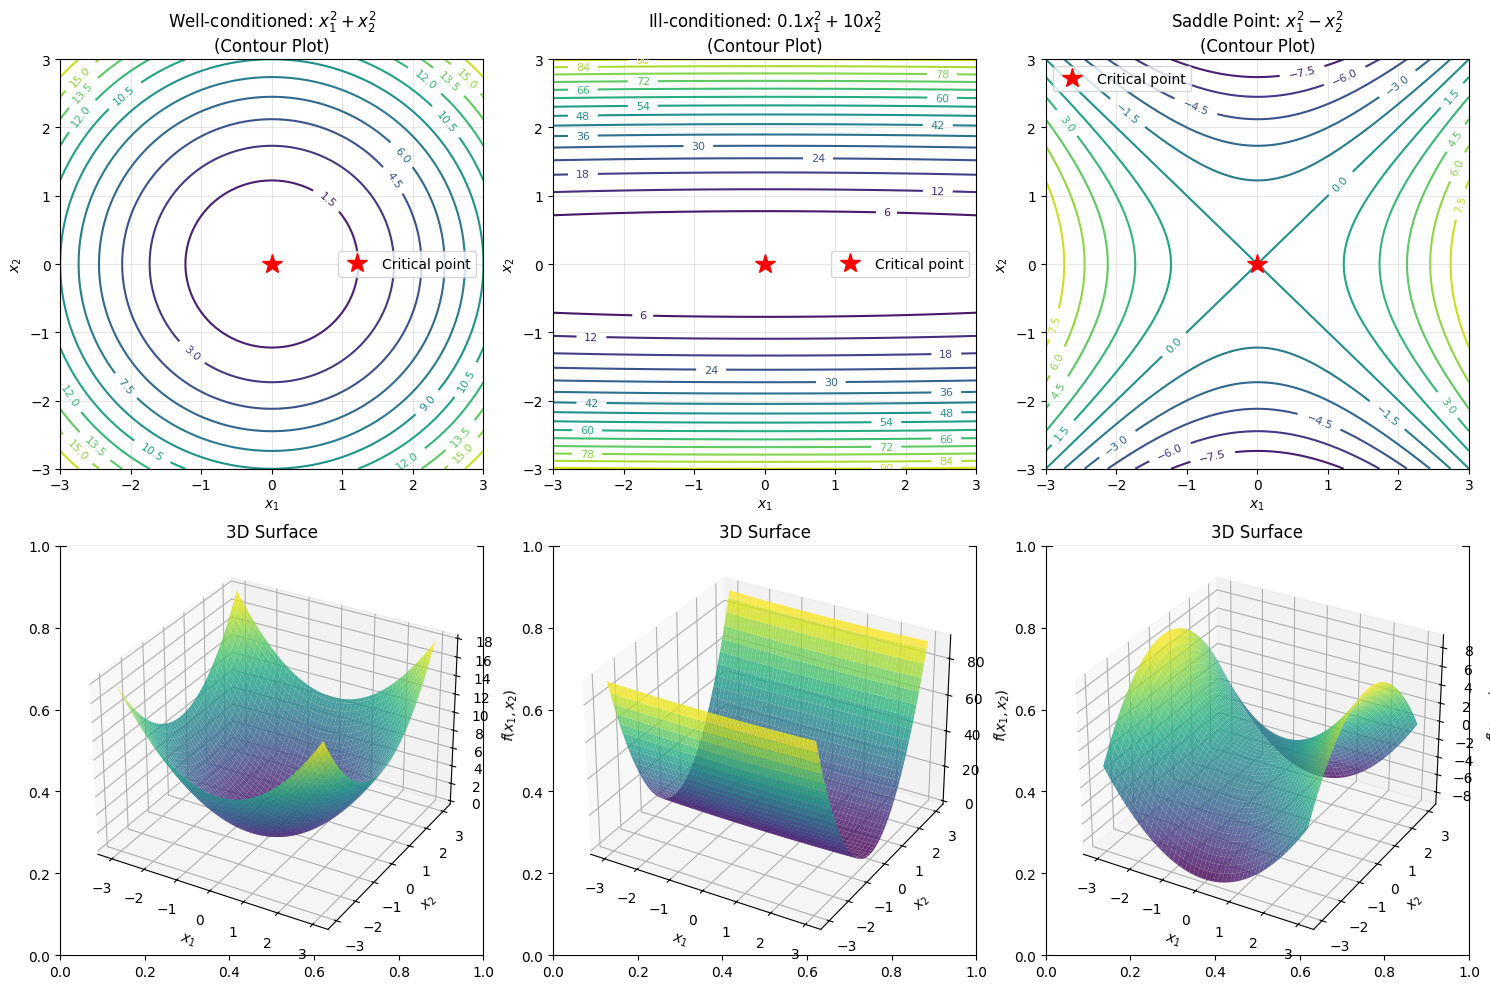

Hessian Analysis

Function 1: f(x1, x2) = x1^2 + x2^2
Hessian: [[2 0]
 [0 2]]
Eigenvalues: [2. 2.]
Condition number: 1.00 → WELL-CONDITIONED

Function 2: f(x1, x2) = 0.1*x1^2 + 10*x2^2
Hessian: [[ 0.2  0. ]
 [ 0.  20. ]]
Eigenvalues: [ 0.2 20. ]
Condition number: 100.00 → ILL-CONDITIONED

Function 3: f(x1, x2) = x1^2 - x2^2 (Saddle)
Hessian: [[ 2  0]
 [ 0 -2]]
Eigenvalues: [ 2. -2.]
Mixed signs → SADDLE POINT


In [7]:
# Visualize Hessian effects on function shape
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Define three functions with different Hessians
# Function 1: Well-conditioned (circular contours)
def f1(x1, x2):
    return x1**2 + x2**2

# Function 2: Ill-conditioned (elongated contours)
def f2(x1, x2):
    return 0.1*x1**2 + 10*x2**2

# Function 3: Saddle point
def f3(x1, x2):
    return x1**2 - x2**2

# Create grid
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

# Plot each function
functions = [f1, f2, f3]
titles = [
    'Well-conditioned: $x_1^2 + x_2^2$',
    'Ill-conditioned: $0.1x_1^2 + 10x_2^2$',
    'Saddle Point: $x_1^2 - x_2^2$'
]

for i, (f, title) in enumerate(zip(functions, titles)):
    # Contour plot
    ax = axes[0, i]
    Z = f(X1, X2)
    contours = ax.contour(X1, X2, Z, levels=15)
    ax.clabel(contours, inline=True, fontsize=8)
    ax.plot(0, 0, 'r*', markersize=15, label='Critical point')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'{title}\n(Contour Plot)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 3D surface plot
    ax = axes[1, i]
    Z = f(X1, X2)
    ax_3d = plt.subplot(2, 3, i+4, projection='3d')
    ax_3d.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
    ax_3d.set_xlabel('$x_1$')
    ax_3d.set_ylabel('$x_2$')
    ax_3d.set_zlabel('$f(x_1, x_2)$')
    ax_3d.set_title('3D Surface')

plt.tight_layout()
plt.show()

# Print Hessian and condition numbers
print("Hessian Analysis")
print("="*50)
print()

print("Function 1: f(x1, x2) = x1^2 + x2^2")
H1 = np.array([[2, 0], [0, 2]])
eig1, _ = np.linalg.eig(H1)
cond1 = np.max(eig1) / np.min(eig1)
print(f"Hessian: {H1}")
print(f"Eigenvalues: {eig1}")
print(f"Condition number: {cond1:.2f} → WELL-CONDITIONED")
print()

print("Function 2: f(x1, x2) = 0.1*x1^2 + 10*x2^2")
H2 = np.array([[0.2, 0], [0, 20]])
eig2, _ = np.linalg.eig(H2)
cond2 = np.max(eig2) / np.min(eig2)
print(f"Hessian: {H2}")
print(f"Eigenvalues: {eig2}")
print(f"Condition number: {cond2:.2f} → ILL-CONDITIONED")
print()

print("Function 3: f(x1, x2) = x1^2 - x2^2 (Saddle)")
H3 = np.array([[2, 0], [0, -2]])
eig3, _ = np.linalg.eig(H3)
print(f"Hessian: {H3}")
print(f"Eigenvalues: {eig3}")
print(f"Mixed signs → SADDLE POINT")

## Summary and Key Takeaways

### What is the Hessian Matrix?

The Hessian is a square matrix of all second-order partial derivatives that captures curvature information about a function.

$\mathbf{H}(\mathbf{x}) = \begin{bmatrix} \frac{\partial^2 f}{\partial x_i \partial x_j} \end{bmatrix}_{i,j}$

### Key Properties

1. **Symmetric**: Mixed partials are equal
2. **Captures curvature**: Contains all second-order information
3. **Eigenvalues matter**: Tell us about function shape and convexity

### Eigenvalue Interpretation

| Eigenvalue Sign | Function Property | Critical Point |
|-----------------|-------------------|----------------|
| All positive | Convex | Local minimum |
| All negative | Concave | Local maximum |
| Mixed | Non-convex | Saddle point |

### Applications in Machine Learning

1. **Optimization**:
   - Newton's method uses Hessian for faster convergence
   - Quasi-Newton methods (BFGS, L-BFGS) approximate the Hessian

2. **Convexity Testing**:
   - Check if loss functions are convex
   - Ensures gradient descent finds global optimum

3. **Critical Point Classification**:
   - Distinguish minima, maxima, and saddle points
   - Important in understanding neural network loss landscapes

4. **Condition Number**:
   - Ratio of eigenvalues determines optimization difficulty
   - High condition number → ill-conditioned problem

### Practical Considerations

- **Computational Cost**: $O(d^2)$ to compute and $O(d^3)$ to invert for $d$ variables
- **Numerical Stability**: Finite difference approximation can be unstable
- **High Dimensions**: Often impractical to compute exactly (use approximations)
- **Importance**: Even when not computed explicitly, understanding Hessian properties helps design better algorithms

### Next Steps

1. Study **gradient descent** algorithms in detail
2. Learn about **quasi-Newton methods** (BFGS, L-BFGS)
3. Explore **Newton's method** for optimization
4. Understand **condition number** and preconditioning
5. Study **backpropagation** for computing Hessian-vector products